In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
def compute_spectra(bins, v, ndft):
    sfdr = np.zeros(len(bins))
    hd3 = np.zeros(len(bins))
    spec_dbv_out = np.zeros((len(bins), ndft//2+1))
    for i in bins:
        y = v[i-1, :]
        y = y[:-1]
        relative_error = (y[-1]-y[-1-ndft])/y[-1]
        print(relative_error)
        y = y[-ndft:]
        spec = np.fft.rfft(y)
        spec_dbv = 20*np.log10(np.abs(spec)/(ndft/2))
        spec_dbv_out[i-1, :] = spec_dbv
        sfdr[i-1] = spec_dbv[i] - np.max(np.delete(spec_dbv, [0, i]))
        hd3[i-1] = spec_dbv[i] - spec_dbv[get_third_harmonic_bin(i, ndft)]
    return sfdr, hd3, spec_dbv_out

In [26]:
def get_third_harmonic_bin(i, ndft):
    """
    Finds the 3rd harmonic bin for a real-valued signal.
    i: fundamental bin index
    nfft: total number of FFT points
    """
    # Step 1: Wrap around the sampling frequency
    wrapped_bin = (3 * i) % ndft
    
    # Step 2: Fold back if it's above Nyquist
    if wrapped_bin > ndft // 2:
        harmonic_bin = ndft - wrapped_bin
    else:
        harmonic_bin = wrapped_bin
        
    return int(harmonic_bin)

In [27]:
df1 = pd.read_csv('./xschem/simulation/tb_boot_bottom_1.txt', sep='\\s+')
df1

,time,v(vi),v(vo)
0,1.900000e-09,0.657404,0.633292
1,3.900000e-09,0.715502,0.692545
2,5.900000e-09,0.768872,0.748055
3,7.900000e-09,0.815329,0.797513
4,9.900000e-09,0.852970,0.838900
...,...,...,...
535,6.390000e-08,0.675264,0.897155
536,6.590000e-08,0.495739,0.301243
537,6.790000e-08,0.732182,0.896431
538,6.990000e-08,0.441251,0.307290


In [28]:
# Parameters
fs = 500e6
ndft = 31
runs = 15
bins = np.arange(1, runs+1)

In [29]:
vi = np.reshape(df1['v(vi)'].values, [runs, len(df1)//runs])
vo = np.reshape(df1['v(vo)'].values, [runs, len(df1)//runs])

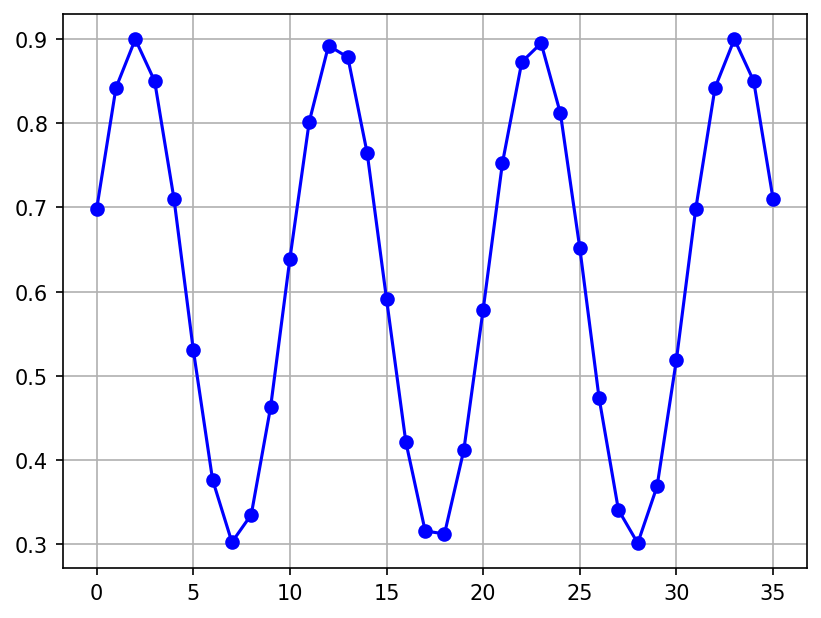

In [30]:
plt.plot(vo[2, :], "b-o")
plt.grid()
plt.show()

In [31]:
hd3_vi = compute_spectra(bins, vi, ndft)[1]
hd3_vo = compute_spectra(bins, vo, ndft)[1]

-1.2264990458657295e-09
4.700723036692823e-08
4.100960721325058e-08
1.5813285059947148e-08
-1.3749054175389078e-06
6.951159110922138e-07
7.794528277576335e-07
1.005728418271767e-08
-1.4428157306734453e-06
-1.0016240017201708e-07
-1.853453298280619e-06
-2.393530551956778e-07
-4.1074470299506235e-06
-7.09876352330053e-06
1.961015385005736e-06
3.887081824144004e-09
3.354593833020562e-08
-4.963965811734801e-08
2.283148642838726e-08
-5.6386842419712564e-08
1.3416181360239788e-06
-2.34131163865113e-08
1.0945001577257275e-07
-5.34528369854843e-08
3.447208262630219e-08
2.6705484454067862e-08
1.7059373795679024e-08
-2.6456227736121108e-08
-8.519256726218639e-08
2.1803509645371426e-08


In [32]:
# Analytical data
vov = 0.734
vm = 0.3
fs = 500e6
fin = bins*fs/ndft
c = 1.3e-12
cb = 400e-15
cp =  20e-15
fbw = 4.9e9
hd3_calc = -20*np.log10((1/2)*fin/fbw*(vm/vov)**2 *(cp/cb+0.1)**2)
print(fbw/1e6)

4900.0


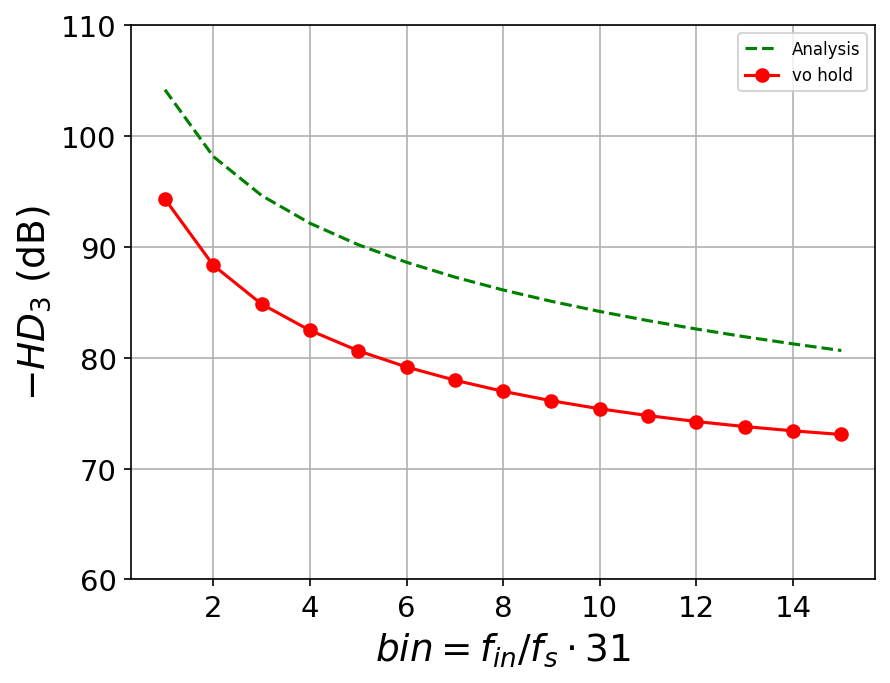

In [33]:
plt.rcParams['figure.dpi'] = 150
plt.plot(bins, hd3_calc, "g--", label='Analysis')
#plt.plot(bins, hd3_vi, "r--", label='vi hold')
plt.plot(bins, hd3_vo, "r-o", label='vo hold')
    
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("$-HD_3$ (dB)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(60, 110)
plt.grid(True)
plt.legend(fontsize=8)
plt.show()

3.887081824144004e-09
3.354593833020562e-08
-4.963965811734801e-08
2.283148642838726e-08
-5.6386842419712564e-08
1.3416181360239788e-06
-2.34131163865113e-08
1.0945001577257275e-07
-5.34528369854843e-08
3.447208262630219e-08
2.6705484454067862e-08
1.7059373795679024e-08
-2.6456227736121108e-08
-8.519256726218639e-08
2.1803509645371426e-08


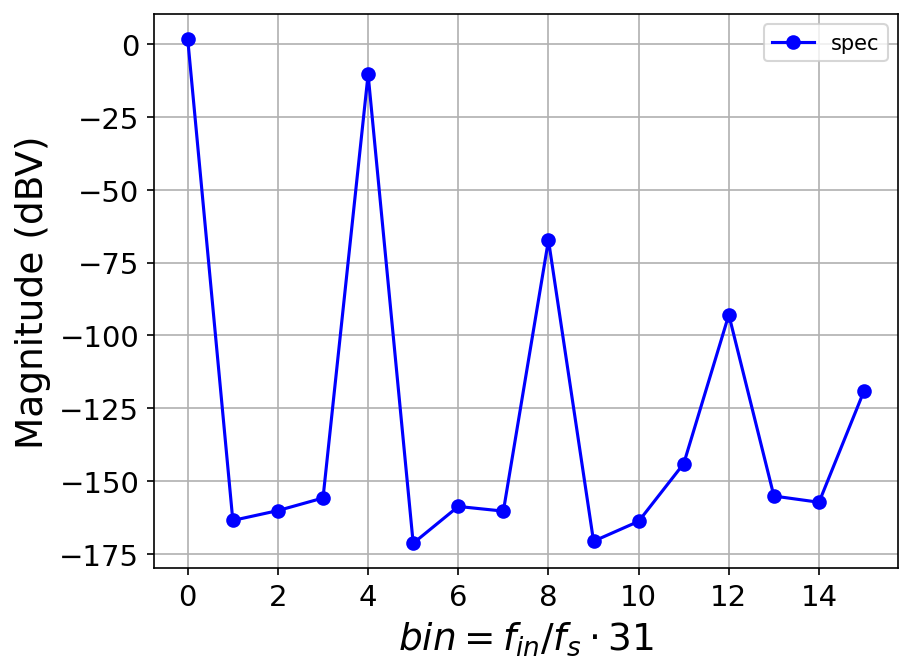

In [34]:
spec_dbv_out = compute_spectra(bins, vo, ndft)[2]

plt.plot(spec_dbv_out[3, :], "b-o", label='spec')
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("Magnitude (dBV)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim(25, 72)
plt.grid(True)
plt.legend()
plt.show()
